In [ ]:
houston13_path = "/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer/data/HyperSpectral-Collections/cls/mat/Houston13.mat"
houston18_path = "/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer/data/HyperSpectral-Collections/cls/mat/Houston18.mat"

In [ ]:
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from PIL import Image

sys.path.append("/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer")
from src.stage1.utilities.losses.repa.feature_pca import feature_pca_torch

/home/office-401/.conda/envs/zihan2/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
d1 = h5py.File(houston13_path)
d1 = d1["ori_data"][:]

(954, 210, 3)


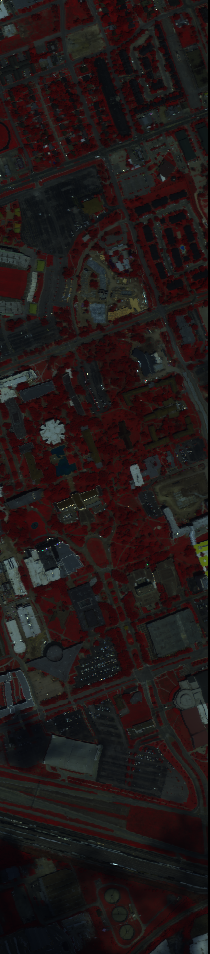

In [ ]:
# Plot
d1_rgb = d1[[29, 19, 9]]
d1_rgb = d1_rgb.transpose(1, 2, 0)
print(d1_rgb.shape)
Image.fromarray((d1_rgb / d1_rgb.max() * 255).astype(np.uint8))

21:28:09 - ⚠️ [WARNING] feature_pca.py:145{} - Number of samples (200340) is greater than feature dimension (48). PCA may be more stable with fewer samples.


21:28:10 - 🔍 [DEBUG] feature_pca.py:187{} - Original shape: torch.Size([1, 48, 954, 210])
21:28:10 - 🔍 [DEBUG] feature_pca.py:188{} - Reshaped for PCA: torch.Size([200340, 48])
21:28:10 - 🔍 [DEBUG] feature_pca.py:189{} - Centered data shape: torch.Size([200340, 48])
21:28:10 - 🔍 [DEBUG] feature_pca.py:191{} - Principal components matrix shape: torch.Size([48, 3])
21:28:10 - 🔍 [DEBUG] feature_pca.py:192{} - Projected data shape (flat): torch.Size([200340, 3])
21:28:10 - 🔍 [DEBUG] feature_pca.py:193{} - Reduced features shape (reshaped): torch.Size([1, 3, 954, 210])


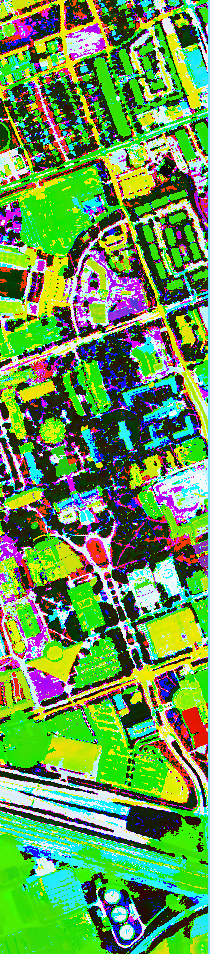

In [52]:
import torch

d1_t = torch.tensor(d1[None])
d1_rgb_pca = feature_pca_torch(d1_t, 3)[0]
d1_rgb_pca = d1_rgb_pca.cpu().numpy().transpose(1, 2, 0)
Image.fromarray((d1_rgb_pca / d1_rgb_pca.max() * 255).astype(np.uint8))

/tmp/ipykernel_2280623/697979830.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_cmap = get_cmap("tab10")


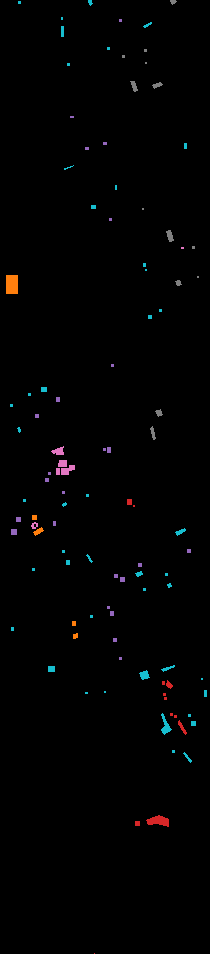

In [ ]:
from matplotlib.cm import get_cmap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize

# 7 gts with colors
base_cmap = get_cmap("tab10")
colors = base_cmap(np.linspace(0, 1, 10))
colors[0] = [0, 0, 0, 1]
custom_cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=np.arange(0, 8), ncolors=10)

gt = h5py.File(
    "/Data4/cao/ZiHanCao/exps/HyperspectralTokenizer/data/HyperSpectral-Collections/cls/cls_GT/Houston13_7gt.mat"
)
gt = gt["map"][:].astype(np.int32)

# to color
gt_rgb = custom_cmap(norm(gt))
Image.fromarray((gt_rgb[:, :, :3] * 255).astype(np.uint8))